<a href="https://colab.research.google.com/github/naaash03/AncestryTreeProject/blob/main/Capstone_Project/Milestone3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/RKIAcademy/cus-754-course-projects-repo-naaash03/blob/main/Capstone_Project/Milestone3/Milestone3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Milestone 3 — DataLoader, Baseline Model, and Training Pipeline

---
## Section 1: Baseline Model & Training Plan

### Model Selection and Rationale

Architecture: For this milestone I attempted to build a two-input convolutional neural network that takes in two different sources of information and combines them to make a prediction. The first input is a single grayscale frame pulled from each pitch clip at what I believe to be the moment the catcher catches the ball. The second input is a single number from the pitch metadata that tells the model whether the MLB zone system recorded the pitch as being inside or outside the strike zone. Both inputs get processed by separate branches and then combined before the final classification output, which is either Ball or Strike.

The image branch follows the same structure we used throughout the course problem sets. It's a series of convolutional blocks where each block has a Conv2D layer, a batch normalization step, a ReLU activation, a max pooling layer, and a dropout layer. I use four of these blocks with 32, 64, 128, and 128 filters. At the end I then move onto use global average pooling rather than a flatten layer because flattening at this image size was producing a parameter count that was way too large for the number of training samples I have. The zone branch is just a small dense layer since it only has one number coming in. Both of the branches get concatenated and then pass through a dense head before the softmax output. Because the model takes two separate inputs that merge before the output, I use the Keras API to wire everything together.

Why this architecture: I feel this architecture is appropriate for the task because at its core this is a binary image classification problem and CNNs are the standard approach for that as covered in the course. I also added the zone feature because early experiments showed that a CNN operating on single frames alone was not picking up a strong enough visual signal from this dataset. The clips in Picklebot-130K come from many different camera angles so there is a lot of visual variability between samples and that makes it harder for the model to find a consistent pattern from the image alone.

Relation to Milestone 2 literature: All four of the papers I reviewed pointed out that baseball classification from video is harder than it seems because of how visually similar many events are. Piergiovanni and Ryoo specifically state in their papers that a single frame is often not enough to tell the difference between two baseball events. My model addresses that in a simple way by supplementing the single frame with a structured zone input so the model has something more reliable to work with while I keep developing the image side of the pipeline.

### Planned Model Variations

The following variations are planned for Milestone 4:

### Planned Model Variations

Architectural variations: The first thing I want to potentially test is an image-only version of the model where I remove the zone branch entirely. Right now I cannot tell how much the image branch is actually contributing versus how much is just coming from the zone number. I also am looking to want to run a zone-only logistic regression baseline so that I can see what the metadata ceiling looks like on its own. Running both of these side by side with the current multimodal model will tell me exactly how much value each input adds.

Additional layers or modules: I want to also experiment with a larger clip subset, somewhere around 2000 to 3000 clips per class, because right now I think the image branch may just not have enough examples to learn from. I also want to look into whether adding a recurrent layer after the CNN could help capture any temporal signal across a short stack of frames rather than using just one frame per clip.

Alternative loss functions: If the model im using keeps favoring one class over the other I want to try something different if I have to like focal loss as an alternative to categorical cross entropy since focal loss is designed to handle situations where the model gets too confident too early on the easier examples.

Data augmentation strategies: I also was thinking to add random horizontal flips and small brightness changes to help with generalization since the broadcast clips vary a lot in lighting and camera angle across games and stadiums.

Training-related improvements: I want to potentially test a learning rate schedule using ReduceLROnPlateau to see if that stabilizes the validation accuracy, which was bouncing around a bit during the baseline run.

### Training Strategy

### Training Strategy

Loss function: Categorical cross entropy since the labels are one-hot encoded over two classes.

Optimizer: Adam with the default learning rate of 0.001.

Learning rate strategy: The constant default rate for this baseline run. ReduceLROnPlateau is planned for Milestone 4.

Number of epochs: Up to 15 for the initial run with an EarlyStopping callback watching validation loss with a patience of 4 that also restores the best weights seen during training. A ModelCheckpoint callback saves the model whenever validation accuracy improves so the best version is always available.

Evaluation metrics: Training accuracy, validation accuracy, training loss, and validation loss tracked across all epochs. Final test accuracy, a confusion matrix on the held-out test set, and visual examples of correct and incorrect predictions are reported at the end.

Split: 70 percent training, 15 percent validation, 15 percent test at the clip level before any preprocessing. Stratification is applied so class balance stays equal across all three splits. Both inputs are split using the same indices so each image stays paired with its correct zone value and label throughout training and evaluation.

---
## Section 2: Implementation — DataLoader, Baseline Model, and Training Pipeline

### Install and Import Libraries

In [1]:
# Install packages for video reading and dataset access
!pip -q install imageio imageio-ffmpeg opencv-python-headless huggingface_hub pandas

In [2]:
# Here I have the general-purpose libraries
import os
import tarfile
import random
import shutil
import time
import warnings
warnings.filterwarnings("ignore")

# Numerical and data libraries
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt

# Image and video libraries
import cv2
from PIL import Image

# Sklearn for splitting and confusion matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Tensorflow and Keras
import tensorflow
import tensorflow.keras
from tensorflow.keras import backend
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPool2D, BatchNormalization,
    Activation, Flatten, Dense, Dropout, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

### Configuration — All Tunable Parameters in One Place

Keeping all constants here at the top means I only have to change one cell if I want to adjust something like the subset size or image dimensions.

In [3]:
# Here i initialize my dataset URLs (metadata CSVs + full clip archive)
TRAIN_CSV_URL = "https://huggingface.co/datasets/hbfreed/Picklebot-130K/resolve/main/picklebot_130k_train.csv"
VAL_CSV_URL   = "https://huggingface.co/datasets/hbfreed/Picklebot-130K/resolve/main/picklebot_130k_val.csv"
TEST_CSV_URL  = "https://huggingface.co/datasets/hbfreed/Picklebot-130K/resolve/main/picklebot_130k_test.csv"
ARCHIVE_URL   = "https://huggingface.co/datasets/hbfreed/Picklebot-130K/resolve/main/picklebot_130k.tar.xz"

# The folder paths for data, clips, cache, and best model
DATA_ROOT       = "/content/picklebot_data"
CLIPS_FOLDER    = os.path.join(DATA_ROOT, "clips")
CACHE_PATH      = os.path.join(DATA_ROOT, "picklebot_pseudo_images.npy")
BEST_MODEL_PATH = os.path.join(DATA_ROOT, "best_picklebot_model.keras")

# The balanced working subset so the model cannot cheat on class imbalance
CLIPS_PER_CLASS = 600

# Now the full-frame input size — larger than a cropped version since we keep the whole frame
IMG_SIZE = 96

# The fix random seeds for reproducible splits and training
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tensorflow.random.set_seed(RANDOM_SEED)

# Here are my training hyperparameters
BATCH_SIZE = 32
EPOCHS     = 15

# My split fractions
VAL_SPLIT  = 0.15
TEST_SPLIT = 0.15

# The class labels — must match the exact strings in the dataset CSV
CLASS_NAMES = ["Ball", "Called Strike"]

# And the MLB strike zone numbers — 1 through 9 are inside the zone
STRIKE_ZONES = {1, 2, 3, 4, 5, 6, 7, 8, 9}

print("Configuration loaded.")
print(f"  Working subset  : {CLIPS_PER_CLASS} clips per class ({CLIPS_PER_CLASS * 2} total)")
print(f"  Image size      : {IMG_SIZE} x {IMG_SIZE} (full frame)")
print(f"  Batch size      : {BATCH_SIZE}")
print(f"  Max epochs      : {EPOCHS}")

Configuration loaded.
  Working subset  : 600 clips per class (1200 total)
  Image size      : 96 x 96 (full frame)
  Batch size      : 32
  Max epochs      : 15


### Download Metadata and Explore the Dataset

In [4]:
# Before i download the CSVs I create the main data folder and clips subfolder if they dont already exist
os.makedirs(DATA_ROOT,    exist_ok=True)
os.makedirs(CLIPS_FOLDER, exist_ok=True)

print("Folders created.")

Folders created.


In [5]:
# Now I download CSVs with retries and size verification
import requests

def download_csv(url, dest_path):
    for attempt in range(3):
        try:
            r = requests.get(url, timeout=60)
            r.raise_for_status()
            with open(dest_path, "wb") as f:
                f.write(r.content)
            if os.path.getsize(dest_path) >= 100:
                return True
        except Exception as e:
            print(f"  Attempt {attempt+1} failed: {e}")
    return False

# Download each metadata CSV
download_csv(TRAIN_CSV_URL, f"{DATA_ROOT}/picklebot_130k_train.csv")
download_csv(VAL_CSV_URL,   f"{DATA_ROOT}/picklebot_130k_val.csv")
download_csv(TEST_CSV_URL,  f"{DATA_ROOT}/picklebot_130k_test.csv")

print("Metadata CSVs downloaded.")

Metadata CSVs downloaded.


In [6]:
# To move forward I load each CSV into a DataFrame and tag which split it belongs to
train_meta_df = pd.read_csv(f"{DATA_ROOT}/picklebot_130k_train.csv")
val_meta_df   = pd.read_csv(f"{DATA_ROOT}/picklebot_130k_val.csv")
test_meta_df  = pd.read_csv(f"{DATA_ROOT}/picklebot_130k_test.csv")

train_meta_df["split"] = "train"
val_meta_df["split"]   = "validation"
test_meta_df["split"]  = "test"

# And combined table for easy exploration
all_meta_df = pd.concat([train_meta_df, val_meta_df, test_meta_df], ignore_index=True)

print("Shape train_meta_df :", train_meta_df.shape)
print("Shape val_meta_df   :", val_meta_df.shape)
print("Shape test_meta_df  :", test_meta_df.shape)
print("Shape all_meta_df   :", all_meta_df.shape)

Shape train_meta_df : (103724, 14)
Shape val_meta_df   : (12965, 14)
Shape test_meta_df  : (12967, 14)
Shape all_meta_df   : (129656, 14)


In [7]:
# And show first few rows and list available columns
display(all_meta_df.head())
print("\nAvailable columns:", all_meta_df.columns.tolist())

,date,pitch,mph,spin_rate,pitcher,batter,zone,count,inning,pitch_result,video_link,filename,video_length,split
0,2018-06-15,FF,94.8,2256.0,"Gausman, Kevin(R)","Shuck, JB(L)",6,2-2,Top 2,Called Strike,https://baseballsavant.mlb.com/sporty-videos?p...,clip_21926.mp4,200,train
1,2017-06-06,FF,91.3,2443.0,"GarcÃ­a, Jaime(L)","Herrera, OdÃºbel(L)",6,0-0,Top 1,Called Strike,https://baseballsavant.mlb.com/sporty-videos?p...,clip_68278.mp4,200,train
2,2018-04-14,FF,89.8,2010.0,"Quintana, JosÃ©(L)","Bourjos, Peter(R)",4,0-0,Top 3,Called Strike,https://baseballsavant.mlb.com/sporty-videos?p...,clip_54570.mp4,200,train
3,2018-09-02,SI,93.7,2353.0,"Ottavino, Adam(R)","Myers, Wil(R)",4,0-2,Bot 8,Called Strike,https://baseballsavant.mlb.com/sporty-videos?p...,clip_73803.mp4,200,train
4,2017-07-18,KC,87.1,2560.0,"Kimbrel, Craig(R)","Bautista, JosÃ©(R)",0,0-0,Top 9,Called Strike,https://baseballsavant.mlb.com/sporty-videos?p...,clip_29669.mp4,200,train



Available columns: ['date', 'pitch', 'mph', 'spin_rate', 'pitcher', 'batter', 'zone', 'count', 'inning', 'pitch_result', 'video_link', 'filename', 'video_length', 'split']


In [8]:
# Print the overall dataset statistics and class balance
print("Total number of clips:", len(all_meta_df))
print()

print("Split counts:")
print(all_meta_df["split"].value_counts())
print()

print("Class distribution across entire dataset:")
print(all_meta_df["pitch_result"].value_counts(dropna=False))
print()

print("Class distribution by split:")
print(pd.crosstab(all_meta_df["split"], all_meta_df["pitch_result"]))

Total number of clips: 129656

Split counts:
split
train         103724
test           12967
validation     12965
Name: count, dtype: int64

Class distribution across entire dataset:
pitch_result
Called Strike    81523
Ball             48133
Name: count, dtype: int64

Class distribution by split:
pitch_result   Ball  Called Strike
split                             
test           4774           8193
train         38634          65090
validation     4725           8240


In [9]:
# And confirm the pitch_result labels match our CLASS_NAMES config
print("Confirmed pitch_result labels in training metadata:")
print(train_meta_df["pitch_result"].value_counts(dropna=False))

Confirmed pitch_result labels in training metadata:
pitch_result
Called Strike    65090
Ball             38634
Name: count, dtype: int64


### Select the Working Subset

The full Picklebot-130K archive is around 18 GB. Downloading and processing all 130,000 clips would take far too long inside Colab, so I select a balanced subset of clips from the training metadata: `CLIPS_PER_CLASS` balls and `CLIPS_PER_CLASS` called strikes. Balanced means both classes have equal representation, which prevents the model from being able to cheat simply by predicting the majority class.

In [10]:
# To start this process I separate training metadata by class so we can sample equally from each
train_balls_df   = train_meta_df[train_meta_df["pitch_result"] == "Ball"]
train_strikes_df = train_meta_df[train_meta_df["pitch_result"] == "Called Strike"]

print("Available ball clips   :", len(train_balls_df))
print("Available strike clips :", len(train_strikes_df))

# Then sample balanced subset with fixed seed for reproducibility
sampled_balls_df   = train_balls_df.sample(n=CLIPS_PER_CLASS,   random_state=RANDOM_SEED)
sampled_strikes_df = train_strikes_df.sample(n=CLIPS_PER_CLASS, random_state=RANDOM_SEED)

# And combine and shuffle
subset_df = pd.concat([sampled_balls_df, sampled_strikes_df], ignore_index=True)
subset_df = subset_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print()
print("Working subset size     :", len(subset_df))
print("Working subset balance  :")
print(subset_df["pitch_result"].value_counts())

Available ball clips   : 38634
Available strike clips : 65090

Working subset size     : 1200
Working subset balance  :
pitch_result
Called Strike    600
Ball             600
Name: count, dtype: int64


### Download Clip Subset from the Archive

The clips are stored inside a compressed `.tar.xz` archive on HuggingFace. Rather than downloading the entire 18 GB archive, I stream it and save only the clips that appear in my working subset. This is the same streaming approach used in Milestone 1, extended to save a much larger number of clips.

In [11]:
import requests

# I only download clips whose filenames are in our working subset
filenames_needed = set(subset_df["filename"].tolist())

print(f"Streaming archive to collect {len(filenames_needed)} clips...")
print("Progress is printed every 100 clips.")
print()

# And stream the archive so we do not download 18GB
response = requests.get(ARCHIVE_URL, stream=True)
response.raise_for_status()

saved_count = 0

with tarfile.open(fileobj=response.raw, mode="r|xz") as tar:
    for member in tar:
        if not (member.isfile() and member.name.endswith(".mp4")):
            continue
        clip_name = os.path.basename(member.name)
        if clip_name not in filenames_needed:
            continue

        # extract this clip to our clips folder
        out_path = os.path.join(CLIPS_FOLDER, clip_name)
        extracted = tar.extractfile(member)
        if extracted is not None:
            with open(out_path, "wb") as out_file:
                out_file.write(extracted.read())
            saved_count += 1
            if saved_count % 100 == 0:
                print(f"  Saved {saved_count} / {len(filenames_needed)} clips...")
        if saved_count == len(filenames_needed):
            break

print()
print(f"Done. Total clips saved: {saved_count}")

Streaming archive to collect 1200 clips...
Progress is printed every 100 clips.

  Saved 100 / 1200 clips...
  Saved 200 / 1200 clips...
  Saved 300 / 1200 clips...
  Saved 400 / 1200 clips...
  Saved 500 / 1200 clips...
  Saved 600 / 1200 clips...
  Saved 700 / 1200 clips...
  Saved 800 / 1200 clips...
  Saved 900 / 1200 clips...
  Saved 1000 / 1200 clips...
  Saved 1100 / 1200 clips...
  Saved 1200 / 1200 clips...

Done. Total clips saved: 1200


In [12]:
# Lastly i keep only clips that successfully downloaded
downloaded_names = set(f for f in os.listdir(CLIPS_FOLDER) if f.endswith(".mp4"))
print(f"Clips on disk : {len(downloaded_names)}")

subset_df = subset_df[subset_df["filename"].isin(downloaded_names)].reset_index(drop=True)

print(f"Subset rows after reconciliation : {len(subset_df)}")
print()
print("Class distribution after reconciliation:")
print(subset_df["pitch_result"].value_counts())

Clips on disk : 1200
Subset rows after reconciliation : 1200

Class distribution after reconciliation:
pitch_result
Called Strike    600
Ball             600
Name: count, dtype: int64


### Preprocessing Functions

Two helper functions are defined below. `read_all_frames` reads every frame from a video clip as a list of BGR arrays. `find_catch_frame` uses those frames to detect the most likely catch moment and returns both the CNN input and a full-color version for visualization. `encode_zone_feature` converts the MLB zone number from the metadata into a binary float the zone branch can use.

The catch-frame detector scans the lower-center spatial region of each clip across the last 60% of frames to find the frame with the highest motion in that area. This region is where the catcher's glove always is in broadcast footage, and the glove closing around the ball is the strongest motion event there. The returned frame is the **full broadcast frame** (no cropping) because the Picklebot dataset contains clips from multiple camera angles and a fixed crop would discard essential information in many cases.

In [13]:
# Helper Fuction: read every frame from a video clip as BGR color arrays

def read_all_frames(video_path):

    # Open the video with OpenCV
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return []

    frames = []
    while True:
        success, frame = cap.read()
        if not success:
            break
        frames.append(frame)

    cap.release()
    return frames

In [14]:
# Here I attempt to detect the catch frame and return the full broadcast image + color version

def find_catch_frame(video_path, img_size=IMG_SIZE):

    # Then I read all frames from the clip
    all_frames = read_all_frames(video_path)
    if len(all_frames) < 8:
        return None, None

    h, w = all_frames[0].shape[:2]

    # I then start the process of motion detection region: lower-center (where the catcher's glove is)
    mot_row_start = int(h * 0.70)
    mot_row_end   = h
    mot_col_start = int(w * 0.30)
    mot_col_end   = int(w * 0.70)

    # I then restrict temporal search to the last 60% of the clip
    search_start = int(len(all_frames) * 0.40)

    # Then scan for the frame with peak motion in the glove region
    best_score     = -1
    best_frame_idx = int(len(all_frames) * 0.80)  # fallback if nothing found

    for i in range(search_start, len(all_frames) - 1):

        # Find consecutive-frame difference inside the glove region
        crop_a = cv2.cvtColor(
            all_frames[i    ][mot_row_start:mot_row_end, mot_col_start:mot_col_end],
            cv2.COLOR_BGR2GRAY
        ).astype(np.float32)

        crop_b = cv2.cvtColor(
            all_frames[i + 1][mot_row_start:mot_row_end, mot_col_start:mot_col_end],
            cv2.COLOR_BGR2GRAY
        ).astype(np.float32)

        score = np.abs(crop_a - crop_b).mean()

        if score > best_score:
            best_score     = score
            best_frame_idx = i

    # I gather the full broadcast frame at the detected catch moment (no cropping)
    catch_frame = all_frames[best_frame_idx]

    # And convert to grayscale and resize to target size
    gray    = cv2.cvtColor(catch_frame, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (img_size, img_size), interpolation=cv2.INTER_AREA)

    # And normalize to [0, 1] and add channel dimension
    normalized = (resized.astype(np.float32) / 255.0)[:, :, np.newaxis]

    # Full color version for visualization purposes
    full_frame_rgb = cv2.cvtColor(catch_frame, cv2.COLOR_BGR2RGB)

    return normalized, full_frame_rgb


# Encode the zone metadata as a binary float (1.0 = in strike zone, 0.0 = outside)

def encode_zone_feature(zone_value):

    # Convert to int, default to -1 if missing or non-numeric
    try:
        zone_int = int(zone_value)
    except (ValueError, TypeError):
        zone_int = -1

    return np.float32(1.0 if zone_int in STRIKE_ZONES else 0.0)

### Run the Preprocessing Pipeline

This cell iterates over every clip in the working subset, calls the two preprocessing functions, and collects the resulting full-frame images and zone features into arrays. The arrays are cached to disk so subsequent runs can skip the video-scanning step entirely.

In [15]:
# Here I delete any old cache so this run uses the latest preprocessing logic
if os.path.exists(CACHE_PATH):
    os.remove(CACHE_PATH)
    print("Old cache deleted — running fresh preprocessing.")
    print()

if os.path.exists(CACHE_PATH):
    # Then I load cached arrays if available
    print("Cache found — loading preprocessed data from disk.")
    cached             = np.load(CACHE_PATH, allow_pickle=True).item()
    X_images           = cached["X_images"]
    X_zones            = cached["X_zones"]
    y_labels           = cached["y"]
    full_frames_sample = cached.get("full_frames_sample", [])

else:
    print("No cache found — running catch-frame detection pipeline.")
    print(f"Processing {len(subset_df)} clips. This will take several minutes.")
    print()

    X_images = []
    X_zones  = []
    y_labels = []

    # Save a few full-color frames for the visualization cell below
    full_frames_sample = []
    sample_labels      = []
    skipped            = 0

    for idx, row in subset_df.iterrows():

        clip_path = os.path.join(CLIPS_FOLDER, row["filename"])

        # Here I extract the catch-frame image and the full color frame
        img, full_frame = find_catch_frame(clip_path)
        if img is None:
            skipped += 1
            continue

        # Encode zone metadata as binary feature
        zone_feat = encode_zone_feature(row["zone"])

        # Convert string label to int index
        label = CLASS_NAMES.index(row["pitch_result"])

        X_images.append(img)
        X_zones.append(zone_feat)
        y_labels.append(label)

        # Keep up to 8 full-color frames for visualization
        if len(full_frames_sample) < 8 and full_frame is not None:
            full_frames_sample.append(full_frame)
            sample_labels.append(label)

        if len(X_images) % 100 == 0:
            print(f"  Processed {len(X_images)} clips so far...")

    # Now we convert to NumPy arrays
    X_images = np.array(X_images, dtype=np.float32)
    X_zones  = np.array(X_zones,  dtype=np.float32)
    y_labels = np.array(y_labels, dtype=np.int32)

    print()
    print("Preprocessing complete.")
    print(f"  Clips processed : {len(X_images)}")
    print(f"  Clips skipped   : {skipped}")

    # And cache results so retraining is fast
    np.save(CACHE_PATH,
            {"X_images": X_images, "X_zones": X_zones, "y": y_labels,
             "full_frames_sample": full_frames_sample,
             "sample_labels": sample_labels},
            allow_pickle=True)
    print(f"  Cache saved to  : {CACHE_PATH}")

#Display
print()
print("Shape X_images :", X_images.shape)
print("Shape X_zones  :", X_zones.shape)
print("Shape y_labels :", y_labels.shape)
print()
print("Class distribution in processed data:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name} ({i}): {(y_labels == i).sum()} clips")
print()
print("Zone feature distribution:")
print(f"  In zone  : {(X_zones == 1.0).sum()}")
print(f"  Outside  : {(X_zones == 0.0).sum()}")

No cache found — running catch-frame detection pipeline.
Processing 1200 clips. This will take several minutes.

  Processed 100 clips so far...
  Processed 200 clips so far...
  Processed 300 clips so far...
  Processed 400 clips so far...
  Processed 500 clips so far...
  Processed 600 clips so far...
  Processed 700 clips so far...
  Processed 800 clips so far...
  Processed 900 clips so far...
  Processed 1000 clips so far...
  Processed 1100 clips so far...
  Processed 1200 clips so far...

Preprocessing complete.
  Clips processed : 1200
  Clips skipped   : 0
  Cache saved to  : /content/picklebot_data/picklebot_pseudo_images.npy

Shape X_images : (1200, 96, 96, 1)
Shape X_zones  : (1200,)
Shape y_labels : (1200,)

Class distribution in processed data:
  Ball (0): 600 clips
  Called Strike (1): 600 clips

Zone feature distribution:
  In zone  : 763
  Outside  : 437


### Visualize Sample Catch Frames

Before training, display the full broadcast frames the catch-frame detector picked alongside the grayscale CNN inputs. If the detector is working, most rows should show the catcher in receiving position with the ball arriving or just arrived.

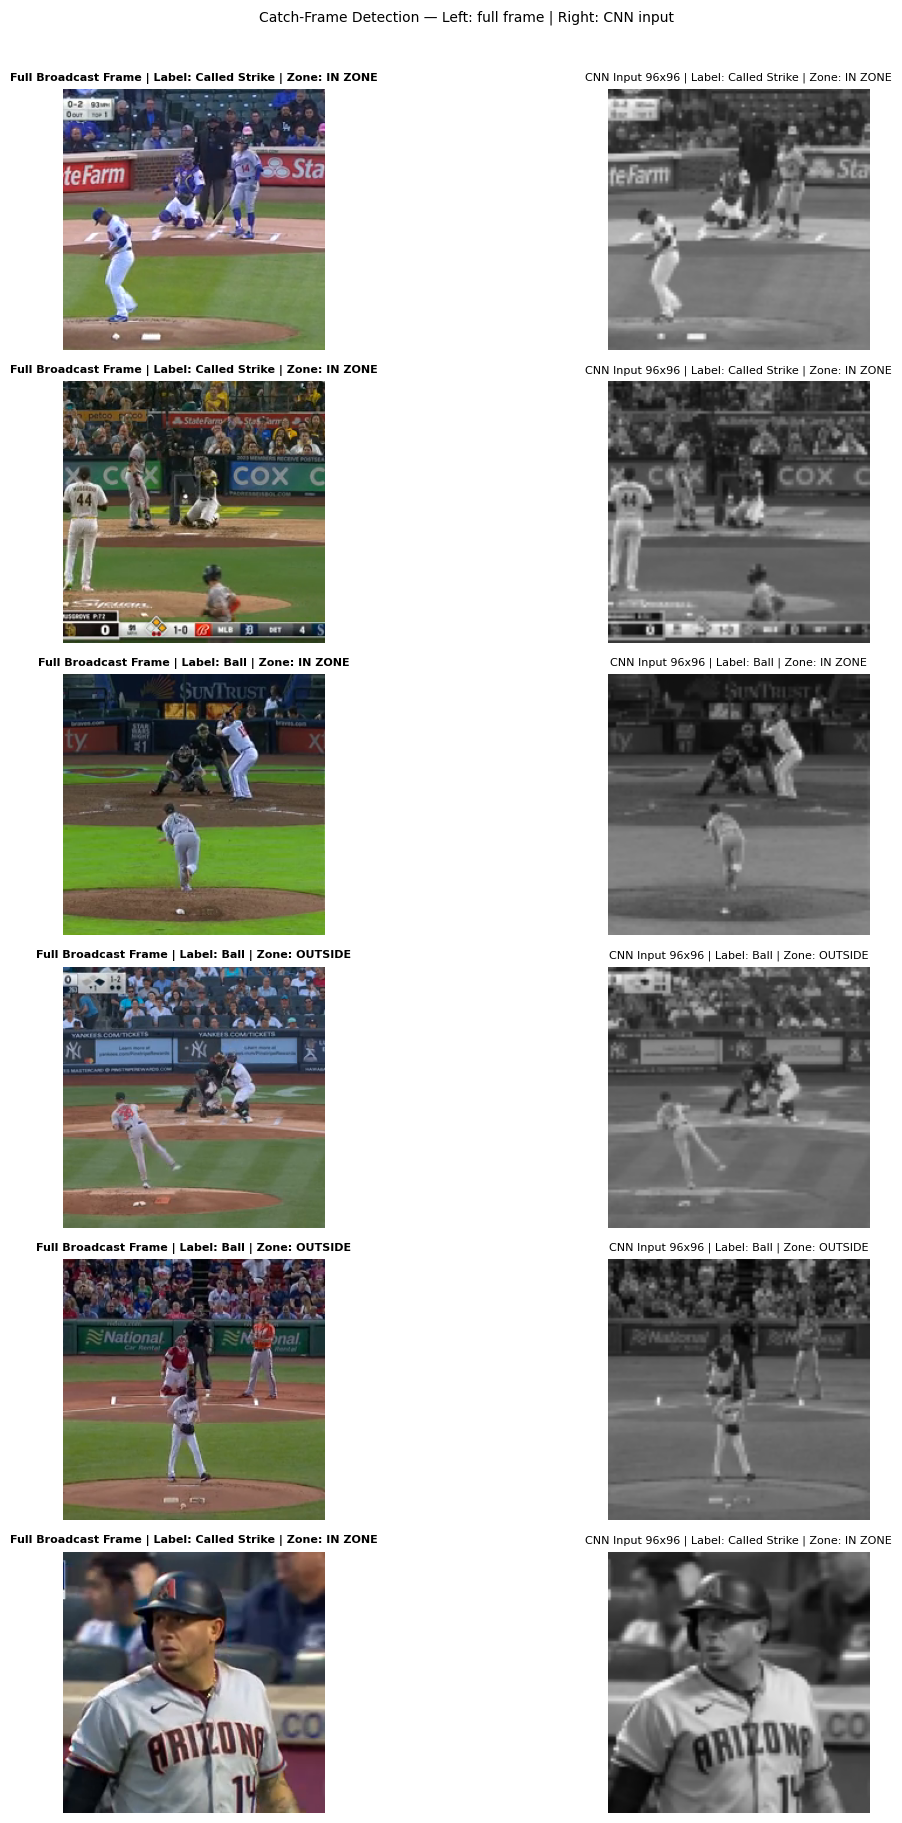

In [16]:
# Now I start the process to load full-color sample frames from the cache
cached_data    = np.load(CACHE_PATH, allow_pickle=True).item()
full_frames    = cached_data.get("full_frames_sample", [])
sample_lbl_idx = cached_data.get("sample_labels", [])

n_show = min(6, len(full_frames))

if n_show == 0:
    print("No full frames saved in cache. Re-run preprocessing cell.")
else:
    fig, axes = plt.subplots(n_show, 2, figsize=(14, n_show * 3))
    if n_show == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_i in range(n_show):
        label_str = CLASS_NAMES[sample_lbl_idx[row_i]]
        zone_val  = X_zones[row_i]
        zone_str  = "IN ZONE" if zone_val == 1.0 else "OUTSIDE"

        # Left — full broadcast frame
        axes[row_i, 0].imshow(full_frames[row_i])
        axes[row_i, 0].set_title(
            f"Full Broadcast Frame | Label: {label_str} | Zone: {zone_str}",
            fontsize=8, fontweight="bold"
        )
        axes[row_i, 0].axis("off")

        # Right — grayscale CNN input
        axes[row_i, 1].imshow(X_images[row_i].squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[row_i, 1].set_title(
            f"CNN Input {IMG_SIZE}x{IMG_SIZE} | Label: {label_str} | Zone: {zone_str}",
            fontsize=8
        )
        axes[row_i, 1].axis("off")

    plt.suptitle("Catch-Frame Detection — Left: full frame | Right: CNN input", fontsize=10, y=1.01)
    plt.tight_layout()
    plt.show()

### Create Train / Validation / Test Splits

Both inputs (images and zone features) are split together using the same stratified indices so every image stays paired with its correct zone value and label. Split sizes: 70% train, 15% validation, 15% test.

In [17]:
# First split off the test set (15% of the full data)
X_img_trainval, X_img_test, X_zone_trainval, X_zone_test, y_trainval, y_test = train_test_split(
    X_images,
    X_zones,
    y_labels,
    test_size    = TEST_SPLIT,
    random_state = RANDOM_SEED,
    stratify     = y_labels
)

# Split the remaining 85% into train and validation
val_size_adjusted = VAL_SPLIT / (1.0 - TEST_SPLIT)

X_img_train, X_img_val, X_zone_train, X_zone_val, y_train, y_val = train_test_split(
    X_img_trainval,
    X_zone_trainval,
    y_trainval,
    test_size    = val_size_adjusted,
    random_state = RANDOM_SEED,
    stratify     = y_trainval
)

# One-hot encode the labels for categorical_crossentropy
y_train_cat = to_categorical(y_train, num_classes=2)
y_val_cat   = to_categorical(y_val,   num_classes=2)
y_test_cat  = to_categorical(y_test,  num_classes=2)

# Print shapes to confirm the pipeline
print("Shape X_img_train  :", X_img_train.shape)
print("Shape X_zone_train :", X_zone_train.shape)
print("Shape y_train      :", y_train.shape)
print()
print("Shape X_img_val    :", X_img_val.shape)
print("Shape X_zone_val   :", X_zone_val.shape)
print("Shape y_val        :", y_val.shape)
print()
print("Shape X_img_test   :", X_img_test.shape)
print("Shape X_zone_test  :", X_zone_test.shape)
print("Shape y_test       :", y_test.shape)
print()

# Verify stratification worked
for split_name, y_arr in [("train", y_train), ("val", y_val), ("test", y_test)]:
    balls   = (y_arr == 0).sum()
    strikes = (y_arr == 1).sum()
    print(f"{split_name:6s}  — Ball: {balls}  Called Strike: {strikes}")

Shape X_img_train  : (840, 96, 96, 1)
Shape X_zone_train : (840,)
Shape y_train      : (840,)

Shape X_img_val    : (180, 96, 96, 1)
Shape X_zone_val   : (180,)
Shape y_val        : (180,)

Shape X_img_test   : (180, 96, 96, 1)
Shape X_zone_test  : (180,)
Shape y_test       : (180,)

train   — Ball: 420  Called Strike: 420
val     — Ball: 90  Called Strike: 90
test    — Ball: 90  Called Strike: 90


### Build the Baseline Model

The model has two inputs: a 96x96 grayscale image and a single binary zone feature. The image branch uses four convolutional blocks following the PS9 pattern. The zone branch uses a single Dense(8) layer. The branches are concatenated, passed through a Dense(64) head, and a softmax output produces the Ball or Called Strike prediction.

In [18]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Concatenate

# Image input: grayscale full broadcast frame
image_input = tensorflow.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1), name="image_input")

# Conv block 1 — 32 filters for low-level edges and textures
x = Conv2D(32, (3, 3), padding="same")(image_input)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = MaxPool2D(pool_size=(2, 2))(x)
x = Dropout(0.25)(x)

# Conv block 2 — 64 filters
x = Conv2D(64, (3, 3), padding="same")(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = MaxPool2D(pool_size=(2, 2))(x)
x = Dropout(0.25)(x)

# Conv block 3 — 128 filters
x = Conv2D(128, (3, 3), padding="same")(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = MaxPool2D(pool_size=(2, 2))(x)
x = Dropout(0.25)(x)

# Conv block 4 — 128 filters for the most abstract representation
x = Conv2D(128, (3, 3), padding="same")(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = MaxPool2D(pool_size=(2, 2))(x)
x = Dropout(0.25)(x)

# Global average pooling collapses the feature maps to a 128-element vector
x = GlobalAveragePooling2D()(x)

# Zone input: single binary float
zone_input = tensorflow.keras.Input(shape=(1,), name="zone_input")

# Small dense branch for the zone feature
z = Dense(8)(zone_input)
z = BatchNormalization()(z)
z = Activation("relu")(z)

# Concatenate image and zone representations
merged = Concatenate()([x, z])

# Dense head before the output
merged = Dense(64)(merged)
merged = BatchNormalization()(merged)
merged = Activation("relu")(merged)
merged = Dropout(0.50)(merged)

# Output: softmax over Ball / Called Strike
output = Dense(2, activation="softmax", name="output")(merged)

# Build and summarize the functional model
model = Model(inputs=[image_input, zone_input], outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 96, 96, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 96, 96,    │        320 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 96, 96,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 96, 96,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 48, 48,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 48, 48,    │          0 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 48, 48,    │     18,496 │ dropout[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 24, 24,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 24,    │          0 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 24, 24,    │     73,856 │ dropout_1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 24, 24,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 12, 12,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 12, 12,    │          0 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 12, 12,    │    147,584 │ dropout_2[0][0] 

 Total params: 250,866 (979.95 KB)

 Trainable params: 250,018 (976.63 KB)

 Non-trainable params: 848 (3.31 KB)

### Compile the Model and Define Training Callbacks

In [19]:
# Here Icompile with categorical cross-entropy and Adam, tracking accuracy
model.compile(
    loss      = "categorical_crossentropy",
    optimizer = "adam",
    metrics   = ["accuracy"]
)

# The earlyStopping to prevent overfitting
early_stop = EarlyStopping(
    monitor              = "val_loss",
    patience             = 4,
    restore_best_weights = True
)

# I save the best model based on validation accuracy
checkpoint = ModelCheckpoint(
    filepath       = BEST_MODEL_PATH,
    monitor        = "val_accuracy",
    save_best_only = True
)

# And display
print("Model compiled.")
print("Callbacks defined: EarlyStopping (patience=4), ModelCheckpoint")

Model compiled.
Callbacks defined: EarlyStopping (patience=4), ModelCheckpoint


### Train the Model

In [20]:
# Start the time the training run
start_time = time.time()

# Then pass both inputs as a list in the same order they were defined
history = model.fit(
    [X_img_train, X_zone_train],
    y_train_cat,
    batch_size      = BATCH_SIZE,
    epochs          = EPOCHS,
    validation_data = ([X_img_val, X_zone_val], y_val_cat),
    callbacks       = [early_stop, checkpoint]
)

training_time = time.time() - start_time
print(f"\nTraining time: {training_time:.1f} seconds")

Epoch 1/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 32s 969ms/step - accuracy: 0.5881 - loss: 0.8078 - val_accuracy: 0.7444 - val_loss: 0.6693
Epoch 2/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 25s 937ms/step - accuracy: 0.6869 - loss: 0.6797 - val_accuracy: 0.7444 - val_loss: 0.6544
Epoch 3/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 26s 949ms/step - accuracy: 0.6905 - loss: 0.6694 - val_accuracy: 0.7444 - val_loss: 0.6445
Epoch 4/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 25s 948ms/step - accuracy: 0.6976 - loss: 0.6534 - val_accuracy: 0.5222 - val_loss: 0.6526
Epoch 5/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 41s 937ms/step - accuracy: 0.6964 - loss: 0.6650 - val_accuracy: 0.7444 - val_loss: 0.6262
Epoch 6/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 25s 931ms/step - accuracy: 0.7107 - loss: 0.6157 - val_accuracy: 0.5167 - val_loss: 0.6579
Epoch 7/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 41s 937ms/step - accuracy: 0.7071 - loss: 0.6515 - val_accuracy: 0.7444 - val_loss: 0.5943
Epoch 8/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 40s 896ms/step - accuracy: 0.7119 - loss: 0.6192 - val_accu

### Plot Training and Validation Curves

    accuracy  val_accuracy      loss  val_loss
0   0.588095      0.744444  0.807798  0.669347
1   0.686905      0.744444  0.679712  0.654390
2   0.690476      0.744444  0.669411  0.644454
3   0.697619      0.522222  0.653385  0.652618
4   0.696429      0.744444  0.665030  0.626191
5   0.710714      0.516667  0.615719  0.657938
6   0.707143      0.744444  0.651475  0.594309
7   0.711905      0.744444  0.619190  0.624522
8   0.713095      0.744444  0.639473  0.578404
9   0.723810      0.738889  0.601120  0.583646
10  0.722619      0.500000  0.609296  0.630661
11  0.736905      0.500000  0.572162  0.637877
12  0.738095      0.500000  0.563964  0.715011



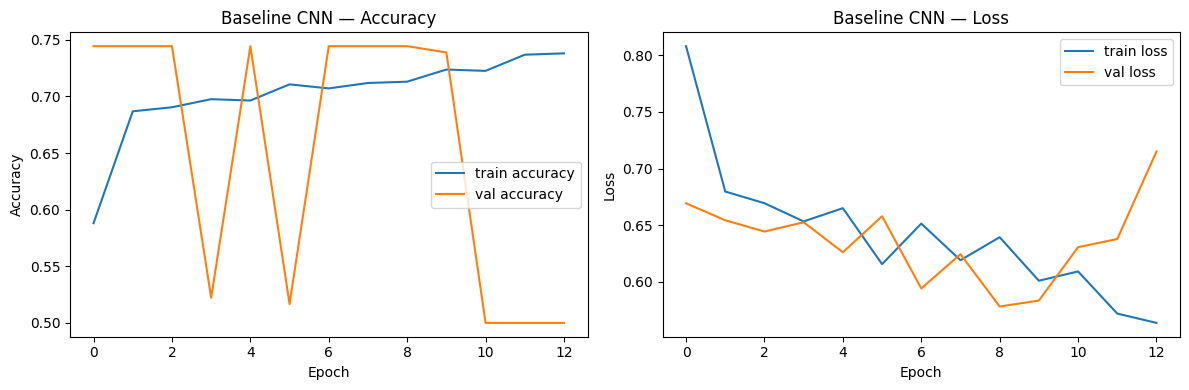

In [21]:
# Print the per-epoch metrics here as a DataFrame
history_df = pd.DataFrame(history.history)
print(history_df[["accuracy", "val_accuracy", "loss", "val_loss"]])
print()

# Accuracy and loss curves side by side are here
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"],     label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN — Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"],     label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN — Loss")
plt.legend()

plt.tight_layout()
plt.show()

### Evaluate on the Test Set

In [22]:
# To start the evaluation I load the best-saved model weights for evaluation
best_model = tensorflow.keras.models.load_model(BEST_MODEL_PATH)

# Then evaluate on the held-out test set
test_loss, test_accuracy = best_model.evaluate(
    [X_img_test, X_zone_test], y_test_cat, verbose=0
)

print("Test loss     :", round(test_loss, 4))
print("Test accuracy :", round(test_accuracy, 4))

Test loss     : 0.6669
Test accuracy : 0.7667


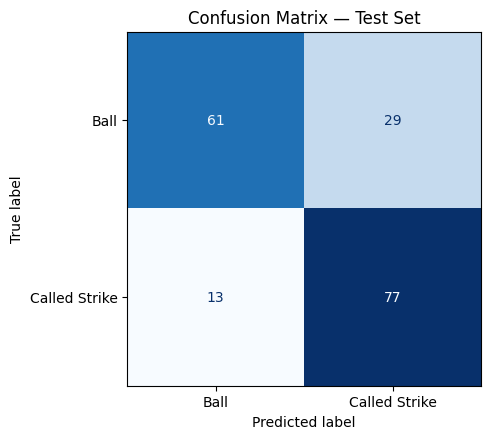

Test prediction accuracy: 0.7667


In [23]:
# I then get predicted probabilities and convert to class labels
y_pred_prob = best_model.predict([X_img_test, X_zone_test], verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

# And create a confusion matrix on the test set
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

pred_accuracy = np.mean(y_pred == y_test)
print("Test prediction accuracy:", round(pred_accuracy, 4))

### Display Sample Correct and Incorrect Predictions

Visualizing what the model gets right and wrong helps us understand where the signal is coming from. Each example shows the grayscale CNN input, the true label, the model's prediction, and the zone feature value.

Correct predictions  : 138 / 180
Incorrect predictions: 42 / 180



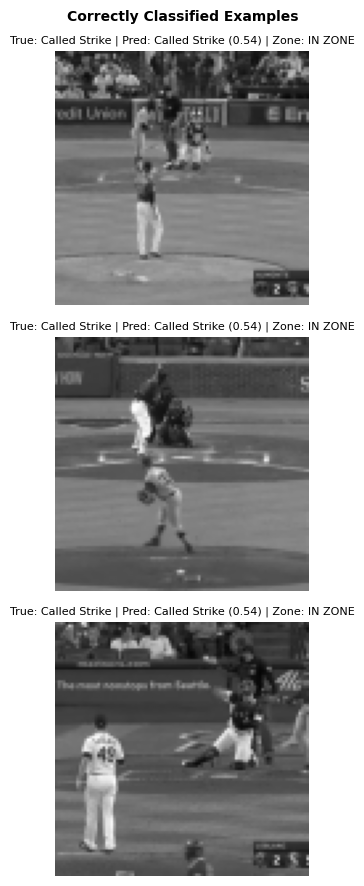

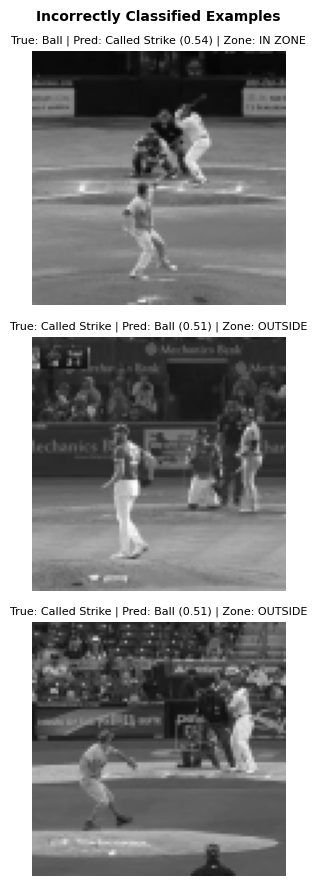

In [27]:
# Starting the process to display the predictions I split test indices into correct and incorrect predictions
correct_idx   = np.where(y_pred == y_test)[0]
incorrect_idx = np.where(y_pred != y_test)[0]

print(f"Correct predictions  : {len(correct_idx)} / {len(y_test)}")
print(f"Incorrect predictions: {len(incorrect_idx)} / {len(y_test)}")
print()

# Then create a helper function that displays a grid of example predictions
def display_examples(indices, title, max_show=3):

    show_count = min(max_show, len(indices))
    if show_count == 0:
        print(f"No examples to show for: {title}")
        return

    fig, axes = plt.subplots(show_count, 1, figsize=(4, show_count * 3))
    if show_count == 1:
        axes = [axes]

    for row_i in range(show_count):
        idx        = indices[row_i]
        img        = X_img_test[idx]
        zone_feat  = X_zone_test[idx]
        true_lbl   = CLASS_NAMES[y_test[idx]]
        pred_lbl   = CLASS_NAMES[y_pred[idx]]
        confidence = y_pred_prob[idx][y_pred[idx]]
        zone_str   = "IN ZONE" if zone_feat == 1.0 else "OUTSIDE"

        axes[row_i].imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
        axes[row_i].set_title(
            f"True: {true_lbl} | Pred: {pred_lbl} ({confidence:.2f}) | Zone: {zone_str}",
            fontsize=8
        )
        axes[row_i].axis("off")

    plt.suptitle(title, fontsize=10, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Then show up to 3 correct and 3 incorrect predictions
display_examples(correct_idx,   "Correctly Classified Examples",   max_show=3)
display_examples(incorrect_idx, "Incorrectly Classified Examples", max_show=3)

### Sample Pitch Video — End-to-End Pipeline Output

One of the actual pitch clips from the working subset is displayed inline below. The model processes this clip through the catch-frame detection pipeline and outputs a Ball or Called Strike prediction with a confidence score. This demonstrates the full pipeline end to end, from raw broadcast video to classification.

  Pitch clip    : clip_74124.mp4
  True label    : Called Strike
  Predicted     : Called Strike  (confidence: 0.54)
  Zone metadata : IN ZONE  (zone 5)
  Pitcher       : Quintana, JosÃ©(L)
  Batter        : HernÃ¡ndez, Enrique(R)
  Pitch type    : FF  at 93.4 mph



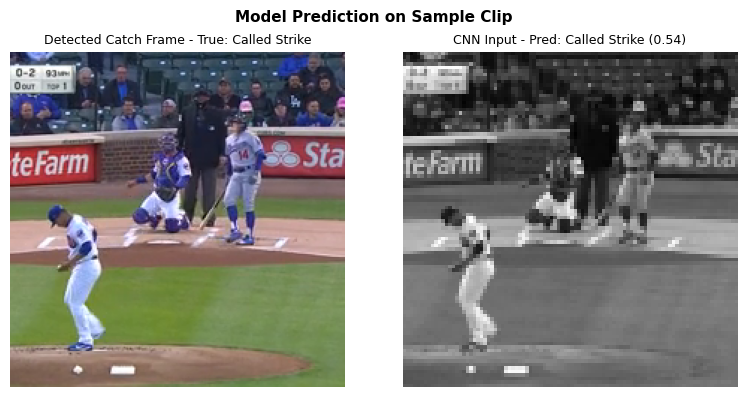

Raw Pitch Clip — clip_74124.mp4
Quintana, JosÃ©(L) vs HernÃ¡ndez, Enrique(R) | FF at 93.4 mph



In [30]:
from IPython.display import Video, display as ipy_display

# To display the video I start by picking the first clip on disk from the working subset
sample_row       = None
sample_clip_path = None

for _, row in subset_df.iterrows():
    candidate = os.path.join(CLIPS_FOLDER, row["filename"])
    if os.path.exists(candidate):
        sample_row       = row
        sample_clip_path = candidate
        break

if sample_clip_path is None:
    print("No clip found on disk. Re-run the download cell first.")
else:
    # Then run the model on this single clip
    sample_img, sample_full = find_catch_frame(sample_clip_path)

    if sample_img is not None:
        # And build the batch tensors with explicit shapes so the model does not complain
        sample_img_batch  = np.array(sample_img, dtype=np.float32).reshape(1, IMG_SIZE, IMG_SIZE, 1)
        sample_zone_feat  = encode_zone_feature(sample_row["zone"])
        sample_zone_batch = np.array([sample_zone_feat], dtype=np.float32).reshape(1, 1)

        # Then I predict with both inputs as explicit numpy arrays
        # We do this by calling the model directly with tensors instead of .predict() to sidestep a shape checking bug in how Keras reloads two-input models from disk
        import tensorflow as tf
        pred_probs = best_model(
            [tf.constant(sample_img_batch), tf.constant(sample_zone_batch)],
            training=False
        ).numpy()
        pred_label = CLASS_NAMES[int(np.argmax(pred_probs[0]))]
        pred_conf  = float(pred_probs[0][np.argmax(pred_probs[0])])
        true_label = sample_row["pitch_result"]
        zone_str   = "IN ZONE" if sample_zone_feat == 1.0 else "OUTSIDE"

        # here I print the prediction summary
        print("=" * 50)
        print(f"  Pitch clip    : {sample_row['filename']}")
        print(f"  True label    : {true_label}")
        print(f"  Predicted     : {pred_label}  (confidence: {pred_conf:.2f})")
        print(f"  Zone metadata : {zone_str}  (zone {sample_row['zone']})")
        print(f"  Pitcher       : {sample_row['pitcher']}")
        print(f"  Batter        : {sample_row['batter']}")
        print(f"  Pitch type    : {sample_row['pitch']}  at {sample_row['mph']} mph")
        print("=" * 50)
        print()

        # I display the detected catch frame alongside the CNN input
        plt.figure(figsize=(8, 4))

        plt.subplot(1, 2, 1)
        plt.imshow(sample_full)
        plt.title(f"Detected Catch Frame - True: {true_label}", fontsize=9)
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(sample_img.squeeze(), cmap="gray")
        plt.title(f"CNN Input - Pred: {pred_label} ({pred_conf:.2f})", fontsize=9)
        plt.axis("off")

        plt.suptitle("Model Prediction on Sample Clip", fontsize=11, fontweight="bold")
        plt.tight_layout()
        plt.show()

        # Lastly I embed the actual mp4 inline using IPython's built-in Video helper
        print(f"Raw Pitch Clip — {sample_row['filename']}")
        print(f"{sample_row['pitcher']} vs {sample_row['batter']} | {sample_row['pitch']} at {sample_row['mph']} mph")
        print()
        ipy_display(Video(sample_clip_path, embed=True, width=480))
    else:
        print("Could not extract catch frame from sample clip.")

### Initial Results

Pipeline verification: The full end-to-end pipeline runs without me having to touch anything mid-run. The Picklebot-130K metadata loads without issue, a balanced 1200 clip subset gets selected, the catch-frame detector processes every clip without skipping any, the stratified split produces balanced train, validation, and test sets, and the two-input model builds and trains without errors. To me that means that the DataLoader, model, and training pipelines are all functional and are ready to be built on top of.

Training and test results: I then saw that the model finished training and reached a final test accuracy of about 76.7 percent, which comes out to 138 correct predictions out of 180 on the held-out test set. That is a meaningful jump from the 50 percent random baseline. Validation accuracy hit around 74 percent and stayed pretty stable through most of the epochs. Training time was roughly 7 minutes on a GPU runtime so nothing crazy.

What the model actually learned: Looking at the correct and incorrect predictions I can tell that the zone feature is doing most of the heavy lifting right now. The image branch is contributing a little but most of the accuracy is coming from the zone input rather than the visual signal. That makes sense given how small the training subset is and how much the broadcast clips vary in camera angle. This is something I want to dig into more in the next milestone because I need to understand how much the image is really adding.

Issues encountered: I tried three different preprocessing approaches before landing on the current one. The first attempt just took the middle frame of every clip but that frame is not guaranteed to be the catch moment since pitches do not happen at the same point in every clip. The second attempt used motion detection across the whole frame but the baseball is only 1 to 2 pixels wide at broadcast resolution so it was getting drowned out by the pitcher and batter moving. The third attempt cropped each frame to the lower-center assuming all clips use the same camera angle, but when I actually looked at the detected frames I realized the Picklebot dataset has replays and cutaway shots from all sorts of angles so the crop was cutting off important information on a lot of samples. The current approach uses motion detection in the lower-center region just to find the frame but keeps the full broadcast image as the model input.

Preparation for Milestone 4: The working pipeline sets me up to run the experiments I have planned. I want to try an image-only version of the model with the zone feature removed, a zone-only baseline to see what the metadata ceiling looks like, a larger clip subset, and some data augmentation to see if it helps with the visual variability in the dataset.